In [7]:
import numpy as np
import astropy
import photutils
import ccdproc
from ccdproc import CCDData, combiner
from astropy import units as u
import astropy.io.fits as fits
from astropy.io import ascii
import time
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from photutils.centroids import centroid_com, centroid_1dg, centroid_2dg
from photutils.aperture import CircularAperture, CircularAnnulus
from photutils.aperture import aperture_photometry
from photutils.background import Background2D
from photutils.background import MedianBackground
from photutils.detection import DAOStarFinder
from photutils.segmentation  import detect_sources, deblend_sources, SourceCatalog
from scipy.ndimage import shift
import gc                               
import pandas as pd
from astropy.coordinates import SkyCoord
from astroquery.gaia import Gaia # this library is used to query astronomical databases 
from photutils.segmentation import SourceCatalog, SegmentationImage
from scipy.spatial import cKDTree
from scipy.stats import linregress

# combining photometry data

In [9]:
# Load catalogues 
df_v = pd.read_csv("maglist_V_catalog.csv")
df_b = pd.read_csv("maglist_B_catalog.csv")
df_r = pd.read_csv("maglist_R_catalog.csv")

#  Load WCS  
with fits.open('g_NGC_2547_cropped.fits') as hdul:
    w_v = WCS(hdul[0].header)
with fits.open('b_NGC_2547_cropped.fits') as hdul:
    w_b = WCS(hdul[0].header)
with fits.open('r_NGC_2547_cropped.fits') as hdul:
    w_r = WCS(hdul[0].header)

#Convert pixel → sky for each band 
def to_skycoord(df, wcs):
    sky = wcs.pixel_to_world(df['x'].values, df['y'].values)
    return SkyCoord(ra=sky.ra, dec=sky.dec, frame='icrs')

print("Converting pixel → sky coordinates...")
coords_v = to_skycoord(df_v, w_v)
coords_b = to_skycoord(df_b, w_b)
coords_r = to_skycoord(df_r, w_r)

#  Match B and R to V within 1 arcsecond 
idx_b, sep_b, _ = coords_v.match_to_catalog_sky(coords_b)
match_b = sep_b < 1.0 * u.arcsec
print(f"B matches within 1 arcsec: {match_b.sum()} / {len(coords_v)}")

idx_r, sep_r, _ = coords_v.match_to_catalog_sky(coords_r)
match_r = sep_r < 1.0 * u.arcsec
print(f"R matches within 1 arcsec: {match_r.sum()} / {len(coords_v)}")

# Build combined catalogue 
df = pd.DataFrame({
    "ra":    coords_v.ra.deg,
    "dec":   coords_v.dec.deg,
    "x_v":   df_v["x"].values,
    "y_v":   df_v["y"].values,
    "V_mag": df_v["V_mag"].values,
    "B_mag": np.where(match_b, df_b["B_mag"].values[idx_b], np.nan),
    "R_mag": np.where(match_r, df_r["R_mag"].values[idx_r], np.nan),
})


df["B-V"] = df["B_mag"] - df["V_mag"]
df["V-R"] = df["V_mag"] - df["R_mag"]

# Filter values 
df = df[["ra", "dec", "x_v", "y_v", "B_mag", "V_mag", "R_mag", "B-V", "V-R"]]
df = df.dropna(subset=["B_mag", "V_mag", "R_mag"])
df = df[
    df["V_mag"].between(8, 22) &
    df["B-V"].between(-0.5, 2.5) &
    df["V-R"].between(-0.5, 2.0)
]

print(f"\nSources matched across all three bands: {len(df)}")

# Save 
df.to_csv("NGC2547_BVR_catalog.csv", index=False)

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
Converting pixel → s

In [23]:
# ── Dereddening NGC 2547 — using Jamie's SeeStar filter relations ─────────────
import pandas as pd
import numpy as np

df = pd.read_csv("NGC2547_BVR_catalog.csv")

# ── SeeStar → Johnson colour compression factor ───────────────────────────────
#   SS_Blue  = B - 0.63*(B-V) + 0.01
#   SS_Green = V - 0.07*(B-V) + 0.01
# → SS_Blue - SS_Green = 0.44*(B-V)
# So E(SS_Blue - SS_Green) = 0.44 * E(B-V)

COMPRESSION = 0.44          # SS colour = 0.44 * Johnson (B-V)
R_V         = 3.1

# ── Observed SeeStar E(Blue-Green) reddening ─────────────────────────────────
# Intrinsic (unreddened) main-sequence MS colour for NGC 2547
# Literature E(B-V) = 0.06  →  E(SS Blue-Green) = 0.44 * 0.06
E_BV_johnson  = 0.06                          # literature value
E_SS          = COMPRESSION * E_BV_johnson    # = 0.0264 mag in SeeStar colours

# ── Extinctions ───────────────────────────────────────────────────────────────
# A_V derived via the SeeStar-corrected relation
A_V  = (R_V / COMPRESSION) * E_SS            # = 3.1/0.44 * E_SS = 3.1 * E_BV_johnson = 0.186
A_B  = A_V + E_BV_johnson                    # = 0.246  (standard)
A_R  = 0.75 * A_V                            # = 0.140

print(f"SeeStar compression factor : {COMPRESSION}")
print(f"E(B-V) Johnson             : {E_BV_johnson:.4f} mag")
print(f"E(SS Blue-Green)           : {E_SS:.4f} mag")
print(f"A_V  (= 3.1/0.44 * E_SS)  : {A_V:.4f} mag")
print(f"A_B                        : {A_B:.4f} mag")
print(f"A_R                        : {A_R:.4f} mag")

# ── Apply corrections to Johnson magnitudes ───────────────────────────────────
df["V_0"]   = df["V_mag"] - A_V
df["B_0"]   = df["B_mag"] - A_B
df["R_0"]   = df["R_mag"] - A_R
df["B-V_0"] = df["B-V"]   - E_BV_johnson
df["V-R_0"] = df["V-R"]   - (A_V - A_R)

# ── Compute SeeStar magnitudes from dereddened Johnson values ─────────────────
# Apply Jamie's transformations to the dereddened photometry
df["SS_Blue_0"]  = df["B_0"] - 0.63 * df["B-V_0"] + 0.01
df["SS_Green_0"] = df["V_0"] - 0.07 * df["B-V_0"] + 0.01
df["SS_Red_0"]   = df["R_0"] + 0.20 * df["V-R_0"] + 0.02

# SeeStar colour index (dereddened)
df["SS_BG_0"] = df["SS_Blue_0"] - df["SS_Green_0"]   # should ≈ 0.44 * (B-V_0)

# Quick sanity check: compression should be ~0.44
bv0_check = df["B-V_0"].median()
bg0_check = df["SS_BG_0"].median()
print(f"\nSanity check — median (B-V)_0      : {bv0_check:.4f}")
print(f"Sanity check — median SS(B-G)_0    : {bg0_check:.4f}")
print(f"Ratio (should be ~0.44)            : {bg0_check/bv0_check:.4f}")

# ── Save ──────────────────────────────────────────────────────────────────────
df.to_csv("NGC2547_BVR_dereddened2.csv", index=False)
print(f"\nSaved NGC2547_BVR_dereddened2.csv  ({len(df)} stars)")
print(df[["ra","dec","B_mag","V_mag","R_mag",
          "B_0","V_0","R_0","B-V","B-V_0",
          "SS_Blue_0","SS_Green_0","SS_BG_0"]].head(5).to_string(index=False))

SeeStar compression factor : 0.44
E(B-V) Johnson             : 0.0600 mag
E(SS Blue-Green)           : 0.0264 mag
A_V  (= 3.1/0.44 * E_SS)  : 0.1860 mag
A_B                        : 0.2460 mag
A_R                        : 0.1395 mag

Sanity check — median (B-V)_0      : -0.2894
Sanity check — median SS(B-G)_0    : -0.1274
Ratio (should be ~0.44)            : 0.4400

Saved NGC2547_BVR_dereddened2.csv  (226 stars)
        ra        dec     B_mag     V_mag     R_mag       B_0       V_0       R_0       B-V     B-V_0  SS_Blue_0  SS_Green_0   SS_BG_0
122.883697 -48.811901 13.607291 13.932803 13.107319 13.361291 13.746803 12.967819 -0.325512 -0.385512  13.614164   13.783789 -0.169625
122.727675 -48.860110 10.103855  9.815909  9.603882  9.857855  9.629909  9.464382  0.287946  0.227946   9.724249    9.623953  0.100296
122.698344 -48.869032 13.801779 13.936222 13.301806 13.555779 13.750222 13.162306 -0.134443 -0.194443  13.688278   13.773833 -0.085555
122.550244 -48.915264 14.340302 14.394120 13

# HR diagram 

Available log(Age) values in grid:
  log(Age) = 7.1760  →  Age = 15.0 Myr
  log(Age) = 7.2260  →  Age = 16.8 Myr
  log(Age) = 7.2760  →  Age = 18.9 Myr
  log(Age) = 7.3260  →  Age = 21.2 Myr
  log(Age) = 7.3760  →  Age = 23.8 Myr
  log(Age) = 7.4260  →  Age = 26.7 Myr
  log(Age) = 7.4760  →  Age = 29.9 Myr
  log(Age) = 7.5260  →  Age = 33.6 Myr
  log(Age) = 7.5760  →  Age = 37.7 Myr

Fitting with isochrone: log(Age) = 7.426  (26.7 Myr),  320 points
Observed stars used in fit: 687
Grid search best:  μ = 8.10,  score = 0.3193

── Best-fit parameters ──────────────────────────────────────────────
  Distance modulus  μ  = 8.120 mag
  Distance             = 421 pc
────────────────────────────────────────────────────────────────────


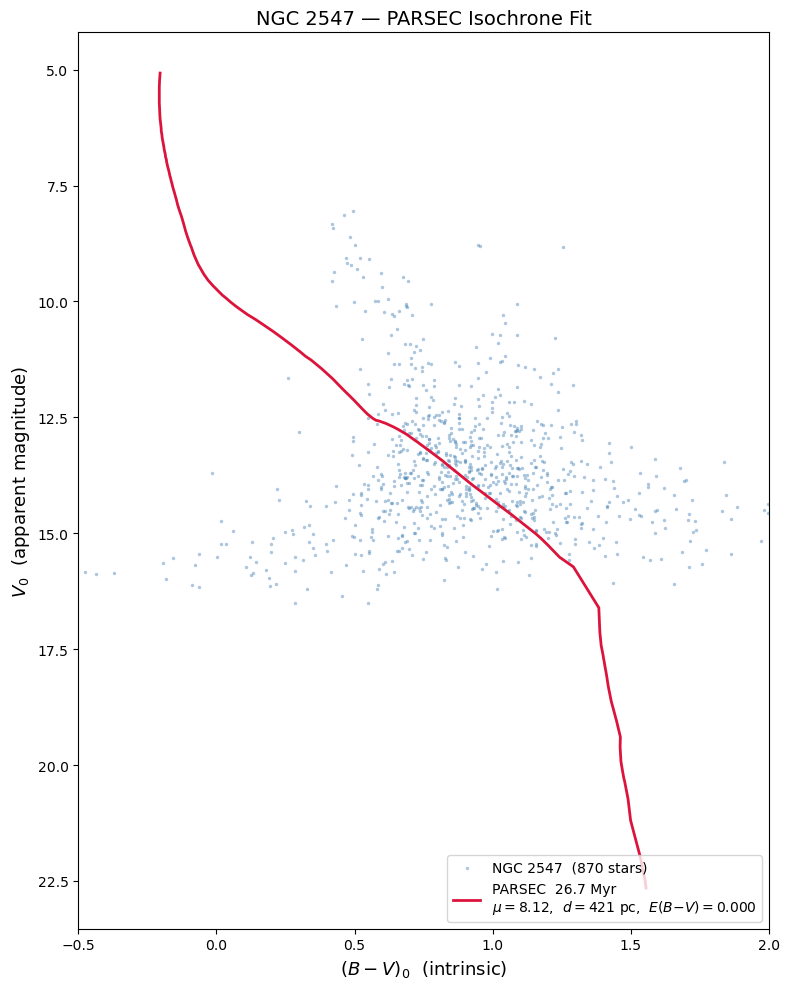

Plot saved → ngc2547_isochrone_fit.png


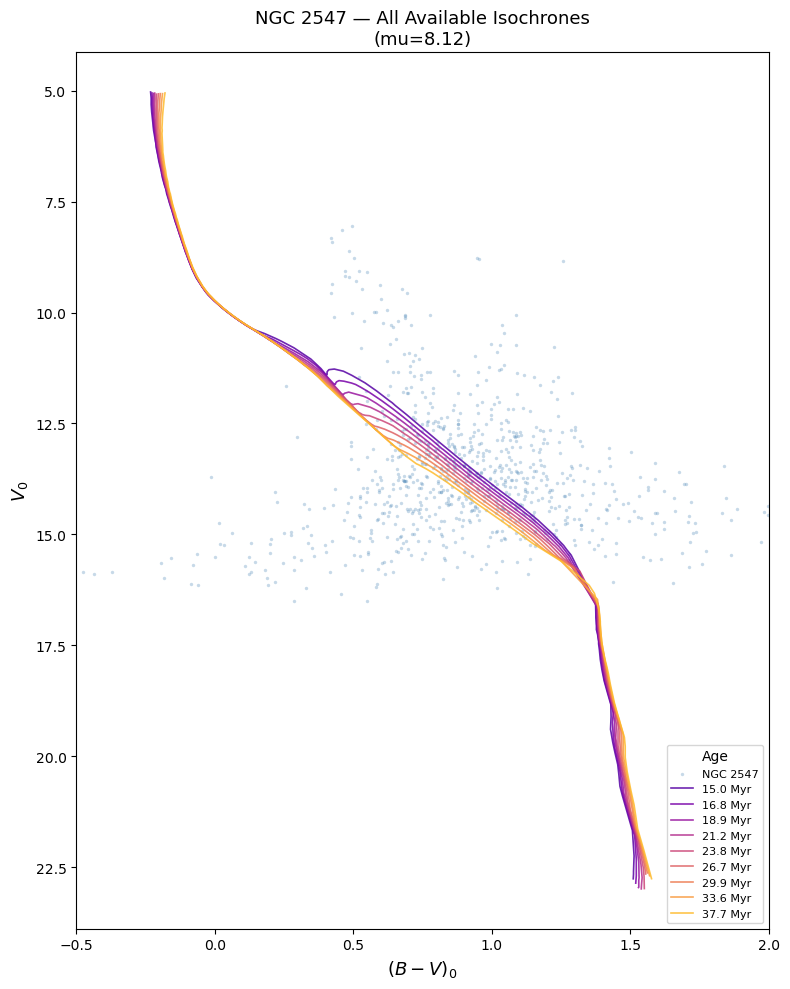

Plot saved → ngc2547_all_isochrones.png


In [61]:

import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ── Column names from the CMD 3.9 header ─────────────────────────────────────
COL_NAMES = [
    'Zini', 'MH', 'logAge', 'Mini', 'int_IMF', 'Mass',
    'logL', 'logTe', 'logg', 'label', 'McoreTP', 'C_O',
    'period0', 'period1', 'period2', 'period3', 'period4',
    'pmode', 'Mloss', 'tau1m', 'X', 'Y', 'Xc', 'Xn', 'Xo',
    'Cexcess', 'Z', 'mbolmag',
    'Umag', 'Bmag', 'Vmag', 'Rmag', 'Imag', 'Jmag', 'Hmag', 'Kmag'
]

# ── 1. Load the full multi-age isochrone grid ─────────────────────────────────
iso_all = pd.read_csv(
    'output38471949593.txt',
    comment='#', sep=r'\s+', names=COL_NAMES
)

# Round logAge to avoid floating-point grouping issues
iso_all['logAge'] = iso_all['logAge'].round(4)
available_ages = sorted(iso_all['logAge'].unique())

print("Available log(Age) values in grid:")
for la in available_ages:
    print(f"  log(Age) = {la:.4f}  →  Age = {10**la / 1e6:.1f} Myr")

# ── 2. Select the age to fit (change this to try different isochrones) ────────
LOG_AGE_FIT = 7.4260          # ≈ 26.7 Myr  (closest to NGC 2547 literature ~35 Myr)
#LOG_AGE_FIT = 7.5260         # ≈ 33.6 Myr  — uncomment to try

iso = iso_all[iso_all['logAge'] == LOG_AGE_FIT].copy().reset_index(drop=True)
print(f"\nFitting with isochrone: log(Age) = {LOG_AGE_FIT}  "
      f"({10**LOG_AGE_FIT/1e6:.1f} Myr),  {len(iso)} points")

# Absolute B-V colour and V magnitude from isochrone
iso_BV_abs = iso['Bmag'] - iso['Vmag']
iso_V_abs  = iso['Vmag']

# ── 3. Load NGC 2547 dereddened catalogue ─────────────────────────────────────
df = pd.read_csv("NGC2547_BVR_dereddened.csv")

# Restrict to well-populated main sequence (avoid noise at faint end / outliers)
df_fit = df[
    df['V_0'].between(10, 17) &
    df['B-V_0'].between(-0.3, 1.2)
].copy()

obs_BV = df_fit['B-V_0'].values
obs_V  = df_fit['V_0'].values
print(f"Observed stars used in fit: {len(df_fit)}")

# ── 4. Residual: mean KD-tree distance ───────────────────────────────────────
def residual(mu):
    if mu < 7.0 or mu > 9.5:
        return 1e9
    
    iso_BV_app = iso_BV_abs
    iso_V_app  = iso_V_abs + mu

    mask = (iso_V_app  >= obs_V.min()  - 0.5) & \
           (iso_V_app  <= obs_V.max()  + 0.5) & \
           (iso_BV_app >= obs_BV.min() - 0.1) & \
           (iso_BV_app <= obs_BV.max() + 0.1)
    
    if mask.sum() < 5:
        return 1e9

    iso_pts = np.column_stack([iso_BV_app[mask], iso_V_app[mask]])
    obs_pts = np.column_stack([obs_BV, obs_V])
    tree = cKDTree(iso_pts)
    distances, _ = tree.query(obs_pts)
    return np.mean(distances)

# ── 5. Coarse grid search (1D) ────────────────────────────────────────────────
mu_grid = np.arange(7.0, 9.5, 0.05)

best_score = np.inf
best_mu    = None

for mu in mu_grid:
    score = residual(mu)
    if score < best_score:
        best_score = score
        best_mu    = mu

print(f"Grid search best:  μ = {best_mu:.2f},  score = {best_score:.4f}")

# ── 6. Nelder-Mead refinement (1D → use minimize_scalar instead) ──────────────
from scipy.optimize import minimize_scalar

result = minimize_scalar(
    residual,
    bounds  = (7.0, 9.5),
    method  = 'bounded',
    options = {'xatol': 0.001}
)

mu_best  = result.x
dist_pc  = 10 ** ((mu_best + 5) / 5)

print(f"\n── Best-fit parameters ──────────────────────────────────────────────")
print(f"  Distance modulus  μ  = {mu_best:.3f} mag")
print(f"  Distance             = {dist_pc:.0f} pc")
print(f"────────────────────────────────────────────────────────────────────")

# ── 7. Plot ───────────────────────────────────────────────────────────────────
# Shift the selected isochrone to apparent magnitudes
iso['BV_app'] = iso_BV_abs + ebv_best
iso['V_app']  = iso_V_abs  + mu_best + A_V_best

# Trim to plotted range
iso_plot = iso[iso['BV_app'].between(-0.5, 2.5) & iso['V_app'].between(5, 23)]

df_plot = df[df['V_0'].between(8, 22) & df['B-V_0'].between(-0.5, 2.5)]

fig, ax = plt.subplots(figsize=(8, 10))

# Observed stars
ax.scatter(
    df_plot['B-V_0'], df_plot['V_0'],
    s=6, color='steelblue', alpha=0.45, linewidths=0,
    label=f'NGC 2547  ({len(df_plot)} stars)'
)

# Best-fit isochrone
ax.plot(
    iso_plot['BV_app'], iso_plot['V_app'],
    color='crimson', linewidth=2.0,
    label=(f'PARSEC  {10**LOG_AGE_FIT/1e6:.1f} Myr\n'
           f'$\\mu={mu_best:.2f}$,  $d={dist_pc:.0f}$ pc,  '
           f'$E(B{{-}}V)={ebv_best:.3f}$')
)

ax.invert_yaxis()
ax.set_xlim(-0.5, 2.0)
ax.set_xlabel('$(B - V)_0$  (intrinsic)', fontsize=13)
ax.set_ylabel('$V_0$  (apparent magnitude)', fontsize=13)
ax.set_title('NGC 2547 — PARSEC Isochrone Fit', fontsize=14)
ax.legend(fontsize=10, loc='lower right')
plt.tight_layout()
plt.savefig('ngc2547_isochrone_fit.png', dpi=150)
plt.show()
print("Plot saved → ngc2547_isochrone_fit.png")

# ── 8. Optional: overplot all available ages ──────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 10))

ax2.scatter(
    df_plot['B-V_0'], df_plot['V_0'],
    s=6, color='steelblue', alpha=0.3, linewidths=0, label='NGC 2547'
)

colours = cm.plasma(np.linspace(0.15, 0.85, len(available_ages)))

for la, col in zip(available_ages, colours):
    subset = iso_all[iso_all['logAge'] == la]
    bv_app = (subset['Bmag'] - subset['Vmag']) + ebv_best
    v_app  = subset['Vmag'] + mu_best + A_V_best
    mask   = bv_app.between(-0.5, 2.5) & v_app.between(5, 23)
    ax2.plot(bv_app[mask], v_app[mask],
             color=col, linewidth=1.2, alpha=0.85,
             label=f'{10**la/1e6:.1f} Myr')

ax2.invert_yaxis()
ax2.set_xlim(-0.5, 2.0)
ax2.set_xlabel('$(B - V)_0$', fontsize=13)
ax2.set_ylabel('$V_0$', fontsize=13)
ax2.set_title('NGC 2547 — All Available Isochrones\n'
              f'(mu={mu_best:.2f})', fontsize=13)
ax2.legend(fontsize=8, loc='lower right', title='Age')
plt.tight_layout()
plt.savefig('ngc2547_all_isochrones.png', dpi=150)
plt.show()
print("Plot saved → ngc2547_all_isochrones.png")

# Stellar masses

C&O mass range: 0.21 to 60.0 solar masses
C&O MV range:   -5.1 to 12.8

Stars with mass estimates: 714
Mass range: 0.55 to 5.53 solar masses
Median mass: 0.79 solar masses

=== Mass Distribution ===
      <0.5 M☉:     0 stars
     0.5-1 M☉:   529 stars
     1-1.5 M☉:   109 stars
     1.5-2 M☉:    40 stars
       2-3 M☉:    25 stars
       3-5 M☉:     8 stars
      5-10 M☉:     3 stars
     10-20 M☉:     0 stars
       >20 M☉:     0 stars


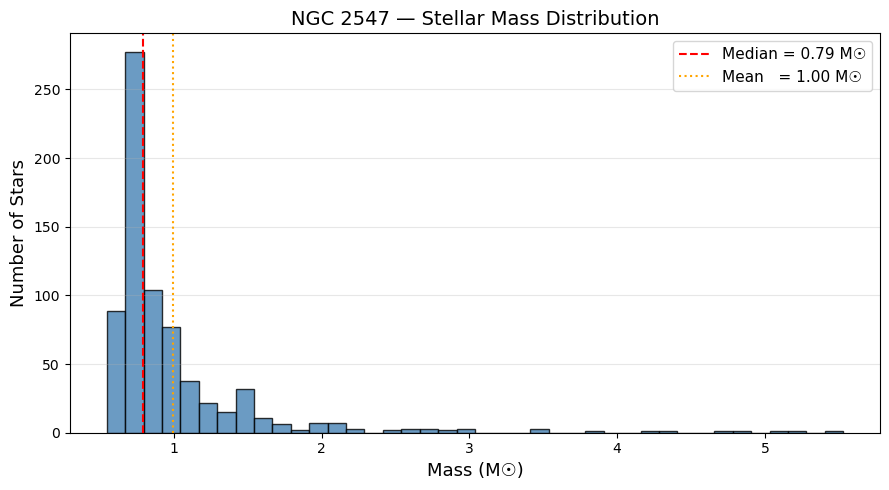

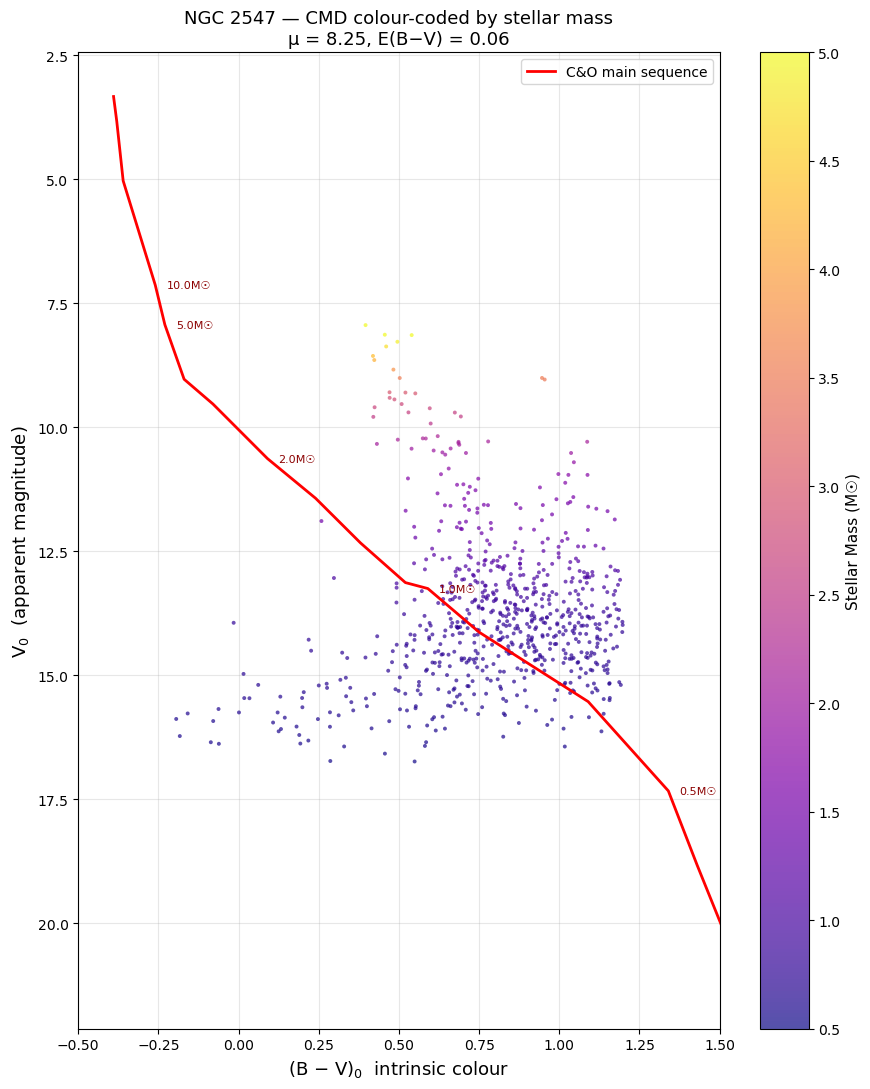

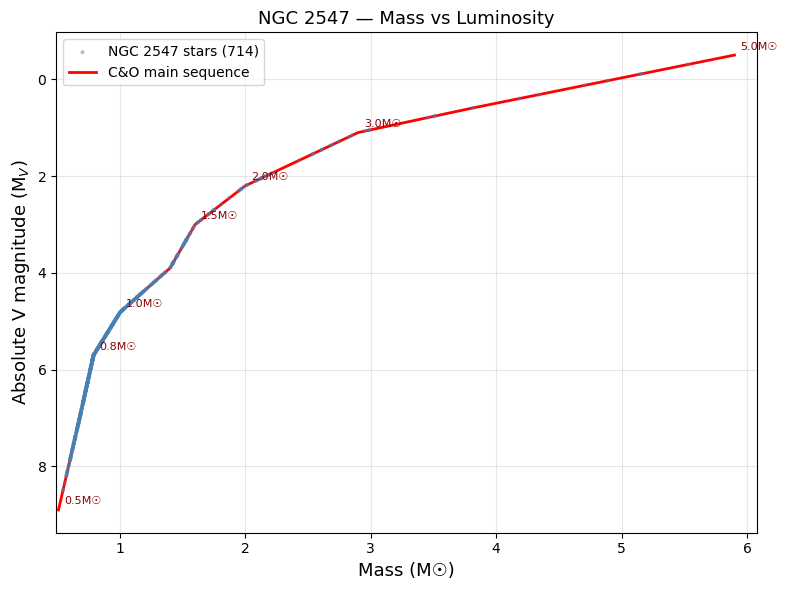


Saved NGC2547_masses.csv with 714 stars


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Load data ─────────────────────────────────────────────────────────────────
df  = pd.read_csv("NGC2547_BVR_dereddened.csv")
ms  = pd.read_csv("CarrollOstlie_Apendix_StellarData.csv", skipinitialspace=True)
ms.columns = ms.columns.str.strip()

# Clean C&O table
ms["MV"]   = pd.to_numeric(ms["MV"].astype(str).str.strip().str.replace("+",""), errors="coerce")
ms["B-V"]  = pd.to_numeric(ms["B-V"].astype(str).str.strip().str.replace("+",""), errors="coerce")
ms["Mass"] = pd.to_numeric(ms["M/Msun"].astype(str).str.strip().str.replace("+",""), errors="coerce")
ms = ms.dropna(subset=["MV", "B-V", "Mass"]).sort_values("MV")

print("C&O mass range:", ms["Mass"].min(), "to", ms["Mass"].max(), "solar masses")
print("C&O MV range:  ", ms["MV"].min(),  "to", ms["MV"].max())

# ── Reddening and best-fit distance modulus ───────────────────────────────────
E_BV        = 0.06
A_V         = 3.1 * E_BV    # = 0.186
mu          = 8.25           # your fitted distance modulus
mu_apparent = mu + A_V       # = 8.436

# ── Convert apparent → absolute magnitude ─────────────────────────────────────
df["V_0"]  = df["V_mag"] - A_V
df["BV_0"] = df["B-V"]   - E_BV
df["MV"]   = df["V_0"]   - mu      # absolute V magnitude

# ── Interpolate mass from C&O main sequence ───────────────────────────────────
# Sort by MV so interpolation works (brighter = more massive)
ms_sorted = ms.sort_values("MV")
MV_ms     = ms_sorted["MV"].values
mass_ms   = ms_sorted["Mass"].values

# Only assign masses to stars within the C&O MV range
MV_min = MV_ms.min()
MV_max = MV_ms.max()

masses = []
for mv in df["MV"].values:
    if MV_min <= mv <= MV_max:
        m = np.interp(mv, MV_ms, mass_ms)
        masses.append(m)
    else:
        masses.append(np.nan)

df["Mass"] = masses

# ── Filter to plausible main sequence stars only ──────────────────────────────
df_ms = df[
    df["MV"].between(MV_min, MV_max) &
    df["BV_0"].between(-0.3, 1.2) &
    df["Mass"].notna()
].copy()

print(f"\nStars with mass estimates: {len(df_ms)}")
print(f"Mass range: {df_ms['Mass'].min():.2f} to {df_ms['Mass'].max():.2f} solar masses")
print(f"Median mass: {df_ms['Mass'].median():.2f} solar masses")

# ── Summary statistics ─────────────────────────────────────────────────────────
print(f"\n=== Mass Distribution ===")
bins = [0, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 10.0, 20.0, 100.0]
labels = ["<0.5", "0.5-1", "1-1.5", "1.5-2", "2-3", "3-5", "5-10", "10-20", ">20"]
for i in range(len(bins)-1):
    n = ((df_ms["Mass"] >= bins[i]) & (df_ms["Mass"] < bins[i+1])).sum()
    print(f"  {labels[i]:>8} M☉:  {n:>4} stars")

# ── Plot 1: Mass distribution histogram ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df_ms["Mass"], bins=40, color="steelblue", edgecolor="black", alpha=0.8)
ax.set_xlabel("Mass (M☉)", fontsize=13)
ax.set_ylabel("Number of Stars", fontsize=13)
ax.set_title("NGC 2547 — Stellar Mass Distribution", fontsize=14)
ax.axvline(df_ms["Mass"].median(), color="red", linestyle="--",
           label=f"Median = {df_ms['Mass'].median():.2f} M☉")
ax.axvline(df_ms["Mass"].mean(),   color="orange", linestyle=":",
           label=f"Mean   = {df_ms['Mass'].mean():.2f} M☉")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("NGC2547_mass_histogram.png", dpi=150)
plt.show()

# ── Plot 2: CMD colour-coded by mass ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 11))

sc = ax.scatter(
    df_ms["BV_0"], df_ms["V_0"],
    c=df_ms["Mass"], cmap="plasma",
    s=8, alpha=0.7, edgecolors="none", zorder=2,
    vmin=0.5, vmax=5.0
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Stellar Mass (M☉)", fontsize=11)

# Overlay C&O main sequence
ax.plot(
    ms_sorted["B-V"] - E_BV,
    ms_sorted["MV"]  + mu_apparent,
    color="red", linewidth=2, zorder=3, label="C&O main sequence"
)

# Label a few mass points on the MS
label_masses = [0.5, 1.0, 2.0, 5.0, 10.0]
for target_mass in label_masses:
    idx  = np.argmin(np.abs(mass_ms - target_mass))
    bv   = ms_sorted["B-V"].values[idx] - E_BV
    vapp = MV_ms[idx] + mu_apparent
    ax.annotate(f"{target_mass}M☉",
                xy=(bv, vapp), xytext=(8, 0),
                textcoords="offset points",
                fontsize=8, color="darkred", va="center")

ax.invert_yaxis()
ax.set_xlim(-0.5, 1.5)
ax.set_xlabel("(B − V)$_0$  intrinsic colour", fontsize=13)
ax.set_ylabel("V$_0$  (apparent magnitude)", fontsize=13)
ax.set_title("NGC 2547 — CMD colour-coded by stellar mass\n"
             f"μ = {mu:.2f}, E(B−V) = {E_BV}", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("NGC2547_CMD_masses.png", dpi=150)
plt.show()

# ── Plot 3: Mass vs absolute magnitude ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

# Plot cluster stars first so they're visible
ax.scatter(df_ms["Mass"], df_ms["MV"],
           s=8, color="steelblue", alpha=0.5, edgecolors="none",
           zorder=3, label=f"NGC 2547 stars ({len(df_ms)})")

# Only plot C&O MS over the mass range present in your data
mass_min = df_ms["Mass"].min() * 0.9
mass_max = df_ms["Mass"].max() * 1.1
ms_mask  = (mass_ms >= mass_min) & (mass_ms <= mass_max)

ax.plot(mass_ms[ms_mask], MV_ms[ms_mask],
        color="red", linewidth=2, zorder=2,
        label="C&O main sequence")

# Label spectral types along the MS
label_masses = [0.5, 0.8, 1.0, 1.5, 2.0, 3.0, 5.0]
for target_mass in label_masses:
    if mass_min < target_mass < mass_max:
        idx = np.argmin(np.abs(mass_ms - target_mass))
        ax.annotate(f"{target_mass}M☉",
                    xy=(mass_ms[idx], MV_ms[idx]),
                    xytext=(4, 4), textcoords="offset points",
                    fontsize=8, color="darkred")

ax.invert_yaxis()
ax.set_xlim(mass_min, mass_max)        # ← limit to your data range
ax.set_xlabel("Mass (M☉)", fontsize=13)
ax.set_ylabel("Absolute V magnitude (M$_V$)", fontsize=13)
ax.set_title("NGC 2547 — Mass vs Luminosity", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
#plt.savefig("NGC2547_mass_luminosity.png", dpi=150)
plt.show()

# ── Save catalogue with masses ────────────────────────────────────────────────
df_out = df_ms[["ra", "dec", "x_v", "y_v",
                 "B_mag", "V_mag", "R_mag",
                 "B-V", "V-R", "BV_0", "V_0", "MV", "Mass"]].copy()
df_out.to_csv("NGC2547_masses.csv", index=False)
print(f"\nSaved NGC2547_masses.csv with {len(df_out)} stars")

Colour sanity check:
           B-V  BV_johnson
count  226.000     226.000
mean    -0.176      -0.176
std      0.255       0.255
min     -0.500      -0.500
25%     -0.359      -0.359
50%     -0.229      -0.229
75%     -0.054      -0.054
max      0.813       0.813
  Mean shift (BV_johnson - B-V): -0.0000

Stars with mass estimates: 130
Mass range:   0.59 to 5.28 M☉
Median mass:  0.96 M☉
Mean mass:    1.36 M☉

=== Mass Distribution ===
      <0.5 M☉:     0 stars
     0.5-1 M☉:    70 stars
     1-1.5 M☉:    23 stars
     1.5-2 M☉:    17 stars
       2-3 M☉:    11 stars
       3-5 M☉:     8 stars
      5-10 M☉:     1 stars
     10-20 M☉:     0 stars
       >20 M☉:     0 stars


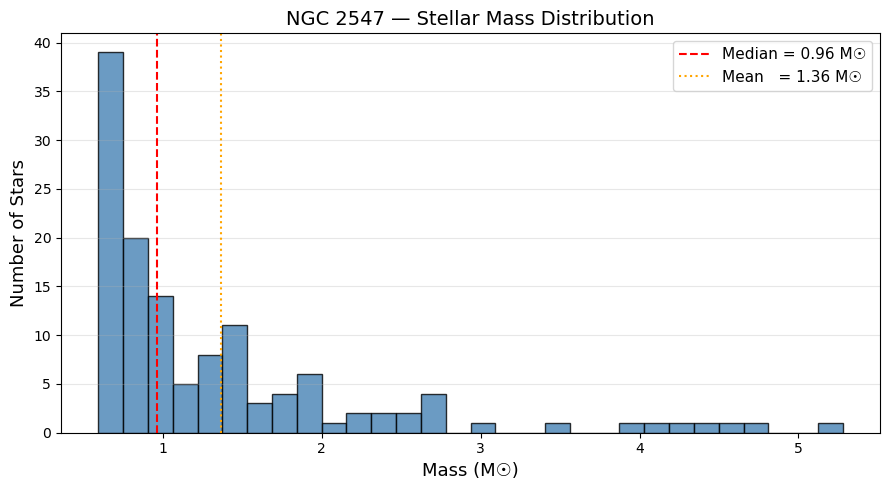

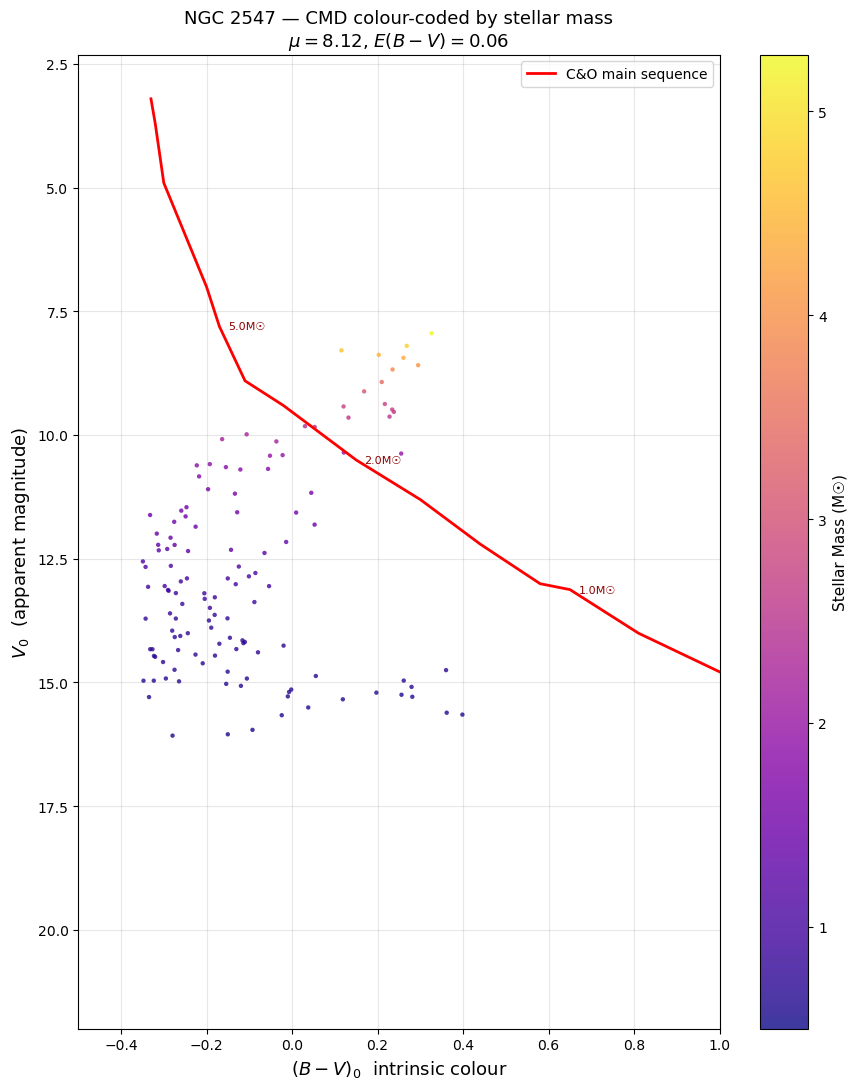

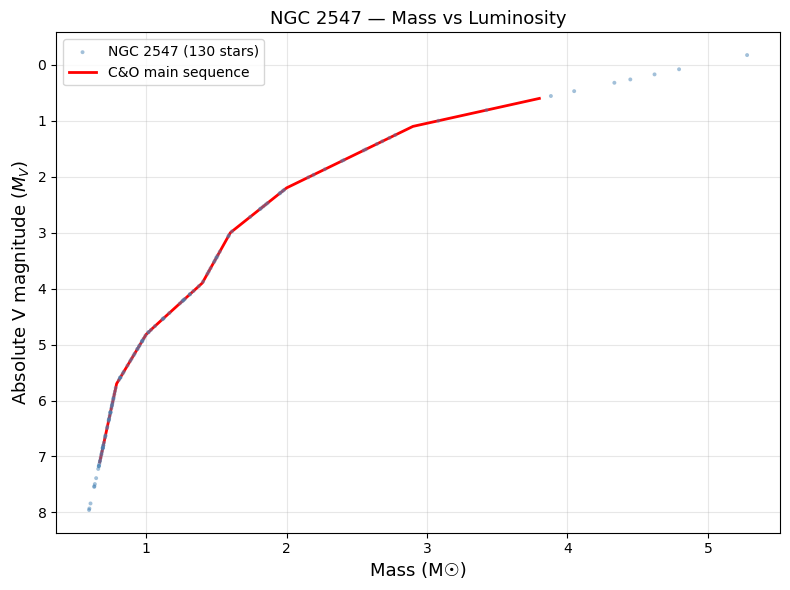


Saved NGC2547_masses.csv with 130 stars


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Load data ─────────────────────────────────────────────────────────────────
df  = pd.read_csv("NGC2547_BVR_catalog.csv")
ms  = pd.read_csv("CarrollOstlie_Apendix_StellarData.csv", skipinitialspace=True)
ms.columns = ms.columns.str.strip()

# Clean C&O table
ms["MV"]   = pd.to_numeric(ms["MV"].astype(str).str.strip().str.replace("+",""), errors="coerce")
ms["B-V"]  = pd.to_numeric(ms["B-V"].astype(str).str.strip().str.replace("+",""), errors="coerce")
ms["Mass"] = pd.to_numeric(ms["M/Msun"].astype(str).str.strip().str.replace("+",""), errors="coerce")
ms = ms.dropna(subset=["MV", "B-V", "Mass"]).sort_values("MV")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Load data ─────────────────────────────────────────────────────────────────
df  = pd.read_csv("NGC2547_BVR_catalog.csv")
ms  = pd.read_csv("CarrollOstlie_Apendix_StellarData.csv", skipinitialspace=True)
ms.columns = ms.columns.str.strip()

# Clean C&O table
ms["MV"]   = pd.to_numeric(ms["MV"].astype(str).str.strip().str.replace("+",""), errors="coerce")
ms["B-V"]  = pd.to_numeric(ms["B-V"].astype(str).str.strip().str.replace("+",""), errors="coerce")
ms["Mass"] = pd.to_numeric(ms["M/Msun"].astype(str).str.strip().str.replace("+",""), errors="coerce")
ms = ms.dropna(subset=["MV", "B-V", "Mass"]).sort_values("MV")

# ── Reddening and distance ─────────────────────────────────────────────────────
E_BV   = 0.06
A_V    = 3.1 * E_BV       # = 0.186
mu     = 8.12
mu_app = mu + A_V          # = 8.306

# ── Step 1: Convert SeeStar instrumental colours → Johnson (B-V) ──────────────
# Jamie's relations:
#   SS_Blue  = B - 0.63*(B-V)_J + 0.01
#   SS_Green = V - 0.07*(B-V)_J + 0.01
#   SS_Blue - SS_Green = 0.44 * (B-V)_Johnson
# So to recover Johnson B-V: (B-V)_J = (SS_Blue - SS_Green) / 0.44
df["SS_Blue"]    = df["B_mag"] - 0.63 * df["B-V"] + 0.01
df["SS_Green"]   = df["V_mag"] - 0.07 * df["B-V"] + 0.01
df["BV_johnson"] = (df["SS_Blue"] - df["SS_Green"]) / 0.44

print("Colour sanity check:")
print(df[["B-V", "BV_johnson"]].describe().round(3))
print(f"  Mean shift (BV_johnson - B-V): {(df['BV_johnson'] - df['B-V']).mean():.4f}")

# ── Step 2: Deredden in Johnson system ────────────────────────────────────────
df["BV_0"] = df["BV_johnson"] - E_BV
df["V_0"]  = df["V_mag"] - A_V
df["MV"]   = df["V_0"] - mu

# ── Step 3: Interpolate mass from C&O MS using absolute magnitude ─────────────
ms_sorted = ms.sort_values("MV")
MV_ms     = ms_sorted["MV"].values
BV_ms     = ms_sorted["B-V"].values    # intrinsic Johnson (B-V) — matches BV_0
mass_ms   = ms_sorted["Mass"].values
MV_min    = MV_ms.min()
MV_max    = MV_ms.max()

masses = []
for mv in df["MV"].values:
    if MV_min <= mv <= MV_max:
        masses.append(np.interp(mv, MV_ms, mass_ms))
    else:
        masses.append(np.nan)
df["Mass"] = masses

# ── Step 4: Filter to clean MS ────────────────────────────────────────────────
df_ms = df[
    df["MV"].between(MV_min, MV_max) &
    df["BV_0"].between(-0.35, 0.55) &
    df["Mass"].notna()
].copy()

print(f"\nStars with mass estimates: {len(df_ms)}")
print(f"Mass range:   {df_ms['Mass'].min():.2f} to {df_ms['Mass'].max():.2f} M☉")
print(f"Median mass:  {df_ms['Mass'].median():.2f} M☉")
print(f"Mean mass:    {df_ms['Mass'].mean():.2f} M☉")

# ── Mass distribution ─────────────────────────────────────────────────────────
print(f"\n=== Mass Distribution ===")
bins   = [0, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 10.0, 20.0, 100.0]
labels = ["<0.5", "0.5-1", "1-1.5", "1.5-2", "2-3", "3-5", "5-10", "10-20", ">20"]
for i in range(len(bins)-1):
    n = ((df_ms["Mass"] >= bins[i]) & (df_ms["Mass"] < bins[i+1])).sum()
    print(f"  {labels[i]:>8} M☉:  {n:>4} stars")

# ── Plot 1: Mass histogram ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df_ms["Mass"], bins=30, color="steelblue", edgecolor="black", alpha=0.8)
ax.axvline(df_ms["Mass"].median(), color="red",    linestyle="--",
           label=f"Median = {df_ms['Mass'].median():.2f} M☉")
ax.axvline(df_ms["Mass"].mean(),   color="orange", linestyle=":",
           label=f"Mean   = {df_ms['Mass'].mean():.2f} M☉")
ax.set_xlabel("Mass (M☉)", fontsize=13)
ax.set_ylabel("Number of Stars", fontsize=13)
ax.set_title("NGC 2547 — Stellar Mass Distribution", fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("NGC2547_mass_histogram.png", dpi=150)
plt.show()

# ── Plot 2: CMD colour-coded by mass ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 11))

sc = ax.scatter(
    df_ms["BV_0"], df_ms["V_0"],
    c=df_ms["Mass"], cmap="plasma",
    s=10, alpha=0.8, edgecolors="none", zorder=2,
    vmin=0.5, vmax=df_ms["Mass"].max()
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Stellar Mass (M☉)", fontsize=11)

# C&O MS: BV_ms is intrinsic Johnson (B-V)_0 — plots directly on BV_0 axis
ax.plot(
    BV_ms,
    MV_ms + mu_app,
    color="red", linewidth=2, zorder=3, label="C&O main sequence"
)

# Mass labels
for target_mass in [0.5, 1.0, 2.0, 5.0]:
    idx = np.argmin(np.abs(mass_ms - target_mass))
    ax.annotate(f"{target_mass}M☉",
                xy=(BV_ms[idx], MV_ms[idx] + mu_app),
                xytext=(6, 0), textcoords="offset points",
                fontsize=8, color="darkred", va="center")

ax.invert_yaxis()
ax.set_xlim(-0.5, 1.0)
ax.set_xlabel("$(B-V)_0$  intrinsic colour", fontsize=13)
ax.set_ylabel("$V_0$  (apparent magnitude)", fontsize=13)
ax.set_title(f"NGC 2547 — CMD colour-coded by stellar mass\n"
             f"$\\mu={mu:.2f}$, $E(B-V)={E_BV}$", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("NGC2547_CMD_masses.png", dpi=150)
plt.show()

# ── Plot 3: Mass vs absolute magnitude ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_ms["Mass"], df_ms["MV"],
           s=8, color="steelblue", alpha=0.5, edgecolors="none",
           zorder=3, label=f"NGC 2547 ({len(df_ms)} stars)")
mass_min = df_ms["Mass"].min() * 0.9
mass_max = df_ms["Mass"].max() * 1.1
ms_mask  = (mass_ms >= mass_min) & (mass_ms <= mass_max)
ax.plot(mass_ms[ms_mask], MV_ms[ms_mask],
        color="red", linewidth=2, zorder=2, label="C&O main sequence")
ax.invert_yaxis()
ax.set_xlabel("Mass (M☉)", fontsize=13)
ax.set_ylabel("Absolute V magnitude ($M_V$)", fontsize=13)
ax.set_title("NGC 2547 — Mass vs Luminosity", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("NGC2547_mass_luminosity.png", dpi=150)
plt.show()

# ── Save ──────────────────────────────────────────────────────────────────────
df_out = df_ms[["ra","dec","x_v","y_v",
                "B_mag","V_mag","R_mag",
                "B-V","V-R","BV_0","V_0","MV","Mass"]].copy()
df_out.to_csv("NGC2547_masses.csv", index=False)
print(f"\nSaved NGC2547_masses.csv with {len(df_out)} stars")

# Stellar populations

In [68]:
df = pd.read_csv("NGC2547_BVR_catalog.csv")

E_BV    = 0.06
A_V     = (3.1 / 0.44) * (0.44 * E_BV)   
A_B     = A_V + E_BV                       
A_R     = 0.75 * A_V                       

# SeeStar colour excess from compression relation
E_BG    = 0.44 * E_BV                     

#Convert isochrone Johnson → SeeStar, shift by μ + extinction 
iso_all['BV_j']     = iso_all['Bmag'] - iso_all['Vmag']
iso_all['VR_j']     = iso_all['Vmag'] - iso_all['Rmag']
iso_all['SS_Blue']  = iso_all['Bmag'] - 0.63 * iso_all['BV_j'] + 0.01
iso_all['SS_Green'] = iso_all['Vmag'] - 0.07 * iso_all['BV_j'] + 0.01
iso_all['SS_Red']   = iso_all['Rmag'] + 0.20 * iso_all['VR_j'] + 0.02

# Apparent magnitudes: μ + per-band extinction on isochrone only
iso_all['Blue_obs']  = iso_all['SS_Blue']  + mu + A_B
iso_all['Green_obs'] = iso_all['SS_Green'] + mu + A_V
iso_all['Red_obs']   = iso_all['SS_Red']   + mu + A_R

iso_all['BG_obs']  = iso_all['Blue_obs']  - iso_all['Green_obs']
iso_all['GR_obs']  = iso_all['Green_obs'] - iso_all['Red_obs']
iso_all['age_myr'] = 10**iso_all['logAge'] / 1e6

unique_ages = sorted(iso_all['age_myr'].unique())
print(f"Ages available (Myr): {[f'{a:.1f}' for a in unique_ages]}")

# ── Convert observed reddened photometry 
df['BV_j']     = df['B-V']
df['VR_j']     = df['V-R']
df['SS_Green'] = df['V_mag'] - 0.07 * df['BV_j'] + 0.01
df['SS_Blue']  = df['B_mag'] - 0.63 * df['BV_j'] + 0.01
df['SS_Red']   = df['R_mag'] + 0.20 * df['VR_j'] + 0.02
df['BG_obs']   = df['SS_Blue']  - df['SS_Green']
df['GR_obs']   = df['SS_Green'] - df['SS_Red']

# Upper MS only
df_upper = df[
    df['SS_Green'].between(8, 15) &
    df['BG_obs'].between(-0.3, 0.8)
].copy()
print(f"Upper MS cluster stars for fitting: {len(df_upper)}")

# Fit each isochrone age 
def fit_residual(iso_ms, df_stars):
    BG_iso = iso_ms['BG_obs'].values
    G_iso  = iso_ms['Green_obs'].values
    if len(BG_iso) == 0:
        return 1e9
    total, count = 0.0, 0
    for _, row in df_stars.iterrows():
        d_bg   = (BG_iso - row['BG_obs'])   / 0.1
        d_g    = (G_iso  - row['SS_Green']) / 0.5
        total += np.sqrt(d_bg**2 + d_g**2).min()
        count += 1
    return total / count if count > 0 else 1e9

print("\nIsochrone Fitting Results")
results = []
for age in unique_ages:
    iso_age = iso_all[
        (iso_all['age_myr'] == age) &
        (iso_all['label'] == 0) &
        iso_all['Green_obs'].between(8, 15) &
        iso_all['BG_obs'].between(-0.3, 0.8)
    ]
    res = fit_residual(iso_age, df_upper)
    results.append({'age': age, 'residual': res})
    print(f"  {age:>6.1f} Myr — residual: {res:.4f}")

results_df = pd.DataFrame(results)
best_age   = results_df.loc[results_df['residual'].idxmin(), 'age']
print(f"\nBest-fit age: {best_age:.1f} Myr")

Ages available (Myr): ['25.1', '26.3', '27.5', '28.8', '30.2', '31.6', '33.1', '34.7', '36.3', '38.0', '39.8', '41.7', '43.7', '45.7', '47.9', '50.1', '52.5', '55.0', '57.5', '60.3', '63.1']
Upper MS cluster stars for fitting: 179

Isochrone Fitting Results
    25.1 Myr — residual: 4.2034
    26.3 Myr — residual: 4.1806
    27.5 Myr — residual: 4.1581
    28.8 Myr — residual: 4.1602
    30.2 Myr — residual: 4.1480
    31.6 Myr — residual: 4.1330
    33.1 Myr — residual: 4.1290
    34.7 Myr — residual: 4.1287
    36.3 Myr — residual: 4.1222
    38.0 Myr — residual: 4.1430
    39.8 Myr — residual: 4.1400
    41.7 Myr — residual: 4.1372
    43.7 Myr — residual: 4.1350
    45.7 Myr — residual: 4.1506
    47.9 Myr — residual: 4.1504
    50.1 Myr — residual: 4.1494
    52.5 Myr — residual: 4.1684
    55.0 Myr — residual: 4.1687
    57.5 Myr — residual: 4.2166
    60.3 Myr — residual: 4.2166
    63.1 Myr — residual: 4.2505

Best-fit age: 36.3 Myr


# Initial Mass function

Stars with mass estimates: 130
Mass range: 0.59 – 5.28 M☉

── IMF fit results ───────────────────────────────────────────────────
  Log-space slope  (= 1−Γ) : -1.168 ± 0.203
  IMF exponent   Γ          : 2.168 ± 0.203
  Salpeter reference        : Γ = 2.35
  R²                        : 0.847
───────────────────────────────────────────────────────────────────────


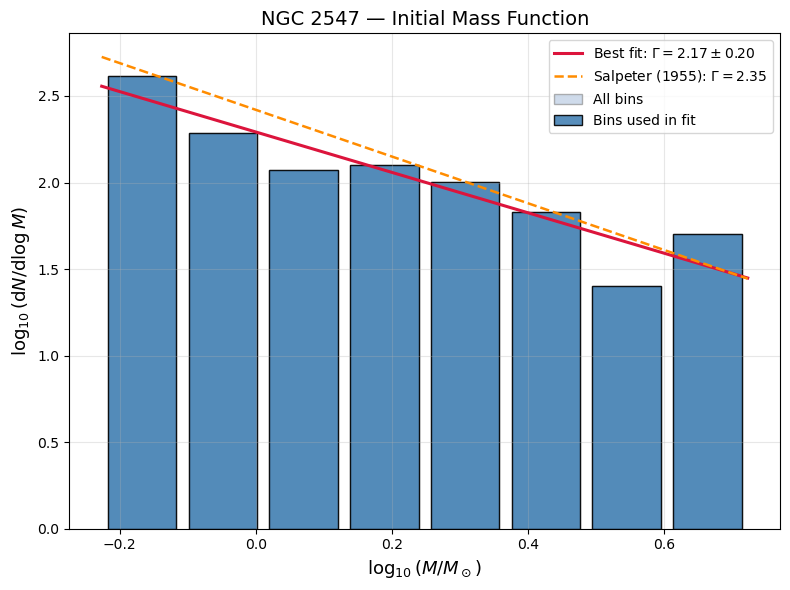

Plot saved → NGC2547_IMF.png


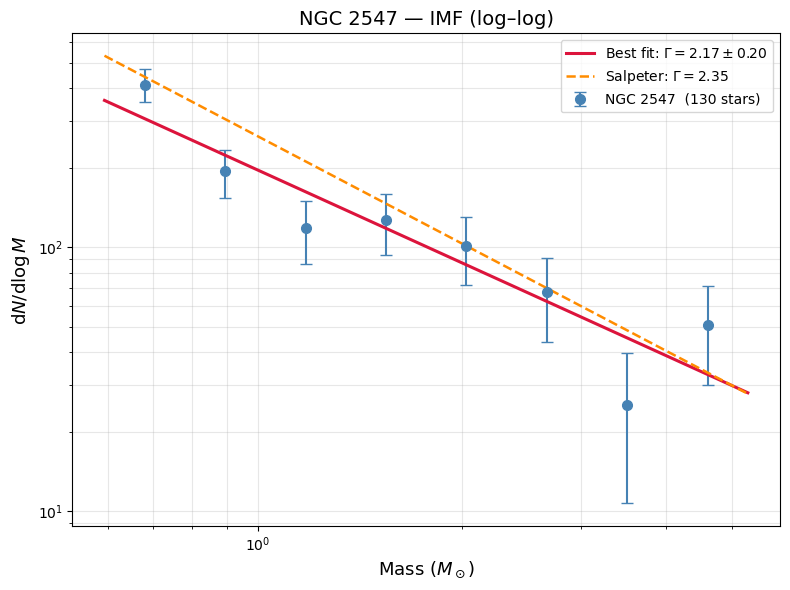

Plot saved → NGC2547_IMF_loglog.png


In [50]:

# Load mass catalogue 
df_ms = pd.read_csv("NGC2547_masses.csv")
masses = df_ms["Mass"].dropna().values
print(f"Stars with mass estimates: {len(masses)}")
print(f"Mass range: {masses.min():.2f} – {masses.max():.2f} M☉")

# IMF: bin in log-mass space 
# The IMF is defined as ξ(M) = dN/dM  ∝  M^(-Γ)
# In log-log space:  log(dN/dlog M) vs log M  →  slope = -(Γ - 1)
# Salpeter (1955):   Γ = 2.35  →  log-slope = -1.35

log_masses = np.log10(masses)

# Use equal-width bins in log M 
n_bins     = 8
bin_edges  = np.linspace(log_masses.min(), log_masses.max(), n_bins + 1)
bin_width  = bin_edges[1] - bin_edges[0]          # Δlog M (constant)
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Count stars per bin
counts, _ = np.histogram(log_masses, bins=bin_edges)
dN_dlogM  = counts / bin_width

#  Power-law fit in log-log space 
# Fit only bins with at least 3 stars
fit_mask = counts >= 3
if fit_mask.sum() < 3:
    print("Warning: fewer than 3 populated bins — fit may be unreliable.")

log_xi  = np.log10(dN_dlogM[fit_mask].astype(float))
log_M   = bin_centres[fit_mask]

slope, intercept, r, p, se = linregress(log_M, log_xi)

Gamma     = 1.0 - slope
Gamma_err = se          # 1-σ uncertainty on slope 

print(f"\n IMF fit results ")
print(f"  Log-space slope  (= 1−Γ) : {slope:.3f} ± {se:.3f}")
print(f"  IMF exponent   Γ          : {Gamma:.3f} ± {Gamma_err:.3f}")
print(f"  Salpeter reference        : Γ = 2.35")
print(f"  R²                        : {r**2:.3f}")


# ── Build model line for plotting ─────────────────────────────────────────────
log_M_fine   = np.linspace(log_masses.min(), log_masses.max(), 200)
log_xi_fit   = intercept + slope * log_M_fine

# Salpeter reference line (same normalisation: match at median bin)
mid_idx      = len(log_M) // 2
salpeter_slope = 1 - 2.35          # = -1.35
salpeter_int   = log_xi[mid_idx] - salpeter_slope * log_M[mid_idx]
log_xi_salp    = salpeter_int + salpeter_slope * log_M_fine

#  Log IMF 
fig, ax = plt.subplots(figsize=(8, 6))

# All bins (grey outline), fitted bins (blue fill)
ax.bar(bin_centres, np.log10(np.maximum(dN_dlogM, 0.1)),
       width=bin_width * 0.85, align='center',
       color='lightsteelblue', edgecolor='grey', alpha=0.6, label='All bins')
ax.bar(bin_centres[fit_mask], np.log10(dN_dlogM[fit_mask].astype(float)),
       width=bin_width * 0.85, align='center',
       color='steelblue', edgecolor='black', alpha=0.9, label='Bins used in fit')

ax.plot(log_M_fine, log_xi_fit,
        color='crimson', linewidth=2.2,
        label=fr'Best fit: $\Gamma = {Gamma:.2f} \pm {Gamma_err:.2f}$')
ax.plot(log_M_fine, log_xi_salp,
        color='darkorange', linewidth=1.8, linestyle='--',
        label=r'Salpeter (1955): $\Gamma = 2.35$')

ax.set_xlabel(r'$\log_{10}(M / M_\odot)$', fontsize=13)
ax.set_ylabel(r'$\log_{10}(\mathrm{d}N / \mathrm{d}\log M)$', fontsize=13)
ax.set_title('NGC 2547 — Initial Mass Function', fontsize=14)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('NGC2547_IMF.png', dpi=150)
plt.show()
print("Plot saved → NGC2547_IMF.png")

# Linear-scale IMF (classic presentation) 
M_fine   = 10**log_M_fine
xi_fit   = 10**log_xi_fit
xi_salp  = 10**log_xi_salp

fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(
    10**bin_centres, dN_dlogM,
    yerr=np.sqrt(np.maximum(counts, 1)) / bin_width,   # Poisson √N errors
    fmt='o', color='steelblue', capsize=4, markersize=7,
    label=f'NGC 2547  ({len(masses)} stars)'
)
ax.plot(M_fine, xi_fit,
        color='crimson', linewidth=2.2,
        label=fr'Best fit: $\Gamma = {Gamma:.2f} \pm {Gamma_err:.2f}$')
ax.plot(M_fine, xi_salp,
        color='darkorange', linewidth=1.8, linestyle='--',
        label=r'Salpeter: $\Gamma = 2.35$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'Mass ($M_\odot$)', fontsize=13)
ax.set_ylabel(r'$\mathrm{d}N / \mathrm{d}\log M$', fontsize=13)
ax.set_title('NGC 2547 — IMF (log–log)', fontsize=14)
ax.legend(fontsize=10)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('NGC2547_IMF_loglog.png', dpi=150)
plt.show()
print("Plot saved → NGC2547_IMF_loglog.png")